In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/Cracks to craters - Ai internship project 2026 Ronak, Osh & Katyayani/Data/pothole-risk/pothole-risk.csv")

In [ ]:
df.head()

,road_id,avg_rainfall_mm,traffic_volume_vph,pavement_age_yrs,soil_type,last_repair_yrs,pothole_risk_label
0,R001,820,4100,12,clay,3,High
1,R002,540,2100,6,gravel,2,Medium
2,R003,2450,6800,9,clay,4,High
3,R004,320,1400,3,sandy,1,Low
4,R005,1600,5000,14,clay,3,High


In [ ]:
df.tail()

,road_id,avg_rainfall_mm,traffic_volume_vph,pavement_age_yrs,soil_type,last_repair_yrs,pothole_risk_label
245,R246,120,900,2,sandy,1,Low
246,R247,2100,5300,10,clay,2,High
247,R248,430,2800,5,gravel,3,Medium
248,R249,720,2200,7,clay,2,Medium
249,R250,90,1000,2,sandy,1,Low


In [ ]:
df.isnull().sum()

,0
road_id,0
avg_rainfall_mm,0
traffic_volume_vph,0
pavement_age_yrs,0
soil_type,0
last_repair_yrs,0
pothole_risk_label,0


In [ ]:
x = df.drop(["road_id", "pothole_risk_label"], axis = 1)
y = df["pothole_risk_label"]
x = pd.get_dummies(x, columns=["soil_type"]) # create new colu,ns on whether its a soil type, with boolean values

In [ ]:
x.head()

,avg_rainfall_mm,traffic_volume_vph,pavement_age_yrs,last_repair_yrs,soil_type_clay,soil_type_gravel,soil_type_sandy
0,820,4100,12,3,True,False,False
1,540,2100,6,2,False,True,False
2,2450,6800,9,4,True,False,False
3,320,1400,3,1,False,False,True
4,1600,5000,14,3,True,False,False


In [ ]:
y.head()

,pothole_risk_label
0,High
1,Medium
2,High
3,Low
4,High


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2, random_state = 42)

In [ ]:
print(type(x_train))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
x_train.shape

(200, 7)

In [ ]:
y_train.shape

(200,)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression(max_iter=5000)

In [ ]:
model.fit(x_train, y_train)

LogisticRegression(max_iter=5000)

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
print(f"Accuracy score: {accuracy_score(y_test, y_pred)}")

Accuracy score: 0.94


In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[22  0  0]
 [ 1 12  1]
 [ 1  0 13]]


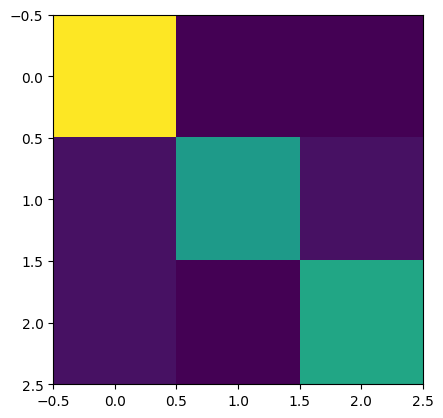

In [ ]:
from matplotlib import pyplot as plt
plt.imshow(cm)

In [ ]:
import pickle

In [ ]:
# exporting the model with pickle to binary
with open("pothole_risk_model.pkl", "wb") as f: # wb = write binary
    pickle.dump(model, f)
with open("feature_columns.txt", "w") as f:
    f.write("\n".join(x_train.columns.tolist())) #separates column names line by line